# Seminário I - Cálculo Numérico


## Bibliotecas Utilizadas


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# configuração visual
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#2a2d3a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
})

## Condição de Aplicabilidade - Teorema de Bolzano


###

1. Verifica se existe uma raiz no intervalo $[a, b]$:

$$f(a) \cdot f(b) < 0$$

Se o produto for negativo os sinais são opostos => há pelo menos uma raíz no intervalo.


In [23]:
def verificar_intervalo(f, a, b):
    """Verifica o Teorema de Bolzano para o intervalo [a, b]."""
    fa, fb = f(a), f(b)
    if fa * fb < 0:
        print(f"Intervalo válido: f({a}) = {fa:.4f}  |  f({b}) = {fb:.4f}")
        print(f"   f(a)·f(b) = {fa*fb:.4f} < 0  -> Existe raiz em [{a}, {b}]")
        return True
    else:
        print(f"Intervalo inválido: f({a}) = {fa:.4f}  |  f({b}) = {fb:.4f}")
        print(f"   f(a)·f(b) = {fa*fb:.4f} ≥ 0  -> Não é garantida raiz em [{a}, {b}]")
        return False

## Método I - Bissecção


###

Bissecção: Divide o intervalo ao meio a cada iteração

A cada passo, calcula o **ponto médio** $m = \dfrac{a+b}{2}$ e descarta a metade do intervalo onde não há troca de sinal.

### Critério de parada

$$|b - a| < \varepsilon \quad \text{ou} \quad |f(m)| < \varepsilon$$

### Convergência

O erro diminui exatamente pela metade a cada iteração: $E_n = \dfrac{b-a}{2^n}$


In [24]:
def bisseccao(f, a, b, tol=1e-6, max_iter=100, verbose=True):
    """
    Método da Bissecção para encontrar raiz de f em [a, b].

    Parâmetros:
        f        : função contínua
        a, b     : extremos do intervalo (f(a)*f(b) < 0)
        tol      : tolerância de parada
        max_iter : número máximo de iterações
        verbose  : imprime tabela de iterações

    Retorna:
        raiz, historico (lista de dicionários com dados de cada iteração)
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) e f(b) devem ter sinais opostos.")

    historico = []

    if verbose:
        print(f"{'Iter':>5} {'a':>12} {'b':>12} {'m':>12} {'f(m)':>14} {'|b-a|':>12}")
        print("-" * 73)

    for i in range(1, max_iter + 1):
        m = (a + b) / 2
        fm = f(m)
        erro = abs(b - a)

        historico.append({'iter': i, 'a': a, 'b': b, 'm': m, 'fm': fm, 'erro': erro})

        if verbose:
            print(f"{i:>5} {a:>12.6f} {b:>12.6f} {m:>12.6f} {fm:>14.8f} {erro:>12.2e}")

        if erro < tol or abs(fm) < tol:
            break

        if f(a) * fm < 0:
            b = m
        else:
            a = m

    if verbose:
        print(f"\nRaiz encontrada: x ≈ {m:.8f}  |  f(x) ≈ {fm:.2e}  |  Iterações: {i}")

    return m, historico

## Método II - Falsa Posição


###

Falsa Posição: Usa interpolação linear para estimar a raiz

Em vez do ponto médio, usa a **reta secante** que passa por $(a,  f(a))$ e $(b,  f(b))$, e toma o ponto onde essa reta cruza o eixo $x$:

$$x_r = b - f(b) \cdot \frac{b - a}{f(b) - f(a)}$$

### Convergência

Geralmente mais rápida que a Bissecção, mas pode ser lenta em casos de curvatura acentuada (problema do "lado preso").


In [25]:
def falsa_posicao(f, a, b, tol=1e-6, max_iter=100, verbose=True):
    """
    Método da Falsa Posição (Regula Falsi) para encontrar raiz de f em [a, b].

    Parâmetros:
        f        : função contínua
        a, b     : extremos do intervalo (f(a)*f(b) < 0)
        tol      : tolerância de parada
        max_iter : número máximo de iterações
        verbose  : imprime tabela de iterações

    Retorna:
        raiz, historico (lista de dicionários com dados de cada iteração)
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) e f(b) devem ter sinais opostos.")

    historico = []

    if verbose:
        print(f"{'Iter':>5} {'a':>12} {'b':>12} {'xr':>12} {'f(xr)':>14} {'|b-a|':>12}")
        print("-" * 73)

    xr_ant = a  # valor anterior para critério de parada relativo

    for i in range(1, max_iter + 1):
        fa, fb = f(a), f(b)
        xr = b - fb * (b - a) / (fb - fa)   # fórmula da falsa posição
        fxr = f(xr)
        erro = abs(b - a)

        historico.append({'iter': i, 'a': a, 'b': b, 'xr': xr, 'fxr': fxr, 'erro': erro})

        if verbose:
            print(f"{i:>5} {a:>12.6f} {b:>12.6f} {xr:>12.6f} {fxr:>14.8f} {erro:>12.2e}")

        if abs(fxr) < tol or erro < tol:
            break

        if fa * fxr < 0:
            b = xr
        else:
            a = xr

        xr_ant = xr

    if verbose:
        print(f"\nRaiz encontrada: x ≈ {xr:.8f}  |  f(x) ≈ {fxr:.2e}  |  Iterações: {i}")

    return xr, historico

## Funções para visualizar os exemplos de cada método (bissecção e falsa posição)


In [26]:
def plotar_funcao_e_raiz(f, a, b, raiz_b, raiz_fp, titulo="", nome_funcao="f(x)"):
    """Plota a função com as raízes encontradas pelos dois métodos."""
    x = np.linspace(a - 0.5, b + 0.5, 800)
    y = f(x)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, y, color='#00d4ff', lw=2.5, label=nome_funcao)
    ax.axhline(0, color='#ffffff', lw=0.8, alpha=0.4)
    ax.axvline(a, color='#aaa', lw=1, ls=':', alpha=0.5, label=f'a = {a}')
    ax.axvline(b, color='#aaa', lw=1, ls=':', alpha=0.5, label=f'b = {b}')

    ax.scatter([raiz_b],  [f(raiz_b)],  color='#ff6b6b', s=120, zorder=5, label=f'Bissecção:      x ≈ {raiz_b:.6f}')
    ax.scatter([raiz_fp], [f(raiz_fp)], color='#ffd93d', s=120, zorder=5, marker='D', label=f'Falsa Posição: x ≈ {raiz_fp:.6f}')

    ax.set_title(titulo, fontsize=13, pad=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plotar_convergencia(hist_b, hist_fp):
    """Compara a convergência dos dois métodos (erro × iteração)."""
    erros_b  = [h['erro'] for h in hist_b]
    erros_fp = [h['erro'] for h in hist_fp]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.semilogy(range(1, len(erros_b) + 1),  erros_b,  'o-', color='#ff6b6b', lw=2, ms=5, label='Bissecção')
    ax.semilogy(range(1, len(erros_fp) + 1), erros_fp, 's-', color='#ffd93d', lw=2, ms=5, label='Falsa Posição')
    ax.set_xlabel('Iteração')
    ax.set_ylabel('Erro  |b − a|  (escala log)')
    ax.set_title('Convergência: Bissecção vs Falsa Posição', fontsize=12)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def plotar_iteracoes_bisseccao(f, hist, a_ini, b_ini, n_mostrar=5):
    """Visualiza as primeiras iterações da Bissecção no gráfico da função."""
    x = np.linspace(a_ini - 0.3, b_ini + 0.3, 600)
    y = f(x)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, y, color='#00d4ff', lw=2.5, label='f(x)')
    ax.axhline(0, color='#ffffff', lw=0.8, alpha=0.4)

    cores = plt.cm.plasma(np.linspace(0.2, 0.9, n_mostrar))
    for k, h in enumerate(hist[:n_mostrar]):
        m = h['m']
        ax.axvline(m, color=cores[k], lw=1.2, ls='--', alpha=0.8, label=f'Iter {h["iter"]}: m={m:.4f}')
        ax.scatter([m], [f(m)], color=cores[k], s=60, zorder=5)

    ax.set_title(f'Bissecção — primeiras {n_mostrar} iterações', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()


def plotar_iteracoes_falsa_posicao(f, hist, a_ini, b_ini, n_mostrar=5):
    """Visualiza as primeiras iterações da Falsa Posição (mostra a reta secante)."""
    x = np.linspace(a_ini - 0.3, b_ini + 0.3, 600)
    y = f(x)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, y, color='#00d4ff', lw=2.5, label='f(x)')
    ax.axhline(0, color='#ffffff', lw=0.8, alpha=0.4)

    cores = plt.cm.inferno(np.linspace(0.2, 0.85, n_mostrar))
    for k, h in enumerate(hist[:n_mostrar]):
        a_k, b_k, xr = h['a'], h['b'], h['xr']
        # reta secante
        ax.plot([a_k, b_k], [f(a_k), f(b_k)], color=cores[k], lw=1.2, ls='--', alpha=0.7)
        ax.scatter([xr], [0], color=cores[k], s=70, zorder=5, label=f'Iter {h["iter"]}: xr={xr:.4f}')

    ax.set_title(f'Falsa Posição — primeiras {n_mostrar} iterações (retas secantes)', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()

## Método III - Newton-Raphson


###

Newton-Raphson: Usa a reta tangente para convergir à raiz

Parte de um **chute inicial** $x_0$ e a cada passo traça a tangente à curva,
tomando onde ela corta o eixo $x$ como nova aproximação:

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

### Critério de parada

$$|x_{n+1} - x_n| < \varepsilon \quad \text{ou} \quad |f(x_n)| < \varepsilon$$

### Convergência

**Quadrática** — o número de casas decimais corretas dobra a cada iteração
(requer $f'(x) \neq 0$ e ponto inicial próximo da raiz).


In [27]:
def newton_raphson(f, df, x0, tol=1e-6, max_iter=100, verbose=True):
    """
    Método de Newton-Raphson para encontrar raiz de f.

    Parâmetros:
        f        : função contínua
        df       : derivada de f
        x0       : chute inicial
        tol      : tolerância de parada
        max_iter : número máximo de iterações
        verbose  : imprime tabela de iterações

    Retorna:
        raiz, historico (lista de dicionários com dados de cada iteração)
    """
    historico = []
    x = x0

    if verbose:
        header = f"{'Iter':>5} {'x':>14} {'f(x)':>14} " + "f'(x)".rjust(14) + f" {'|Δx|':>12}"
        print(header)

    for i in range(1, max_iter + 1):
        fx  = f(x)
        dfx = df(x)

        if abs(dfx) < 1e-10:
            raise ValueError(f"Derivada nula em x = {x:.6f}. Método falhou.")

        dx    = fx / dfx
        x_novo = x - dx
        erro  = abs(dx)

        historico.append({'iter': i, 'x': x, 'fx': fx, 'dfx': dfx, 'erro': erro})

        if verbose:
            print(f"{i:>5} {x:>14.8f} {fx:>14.8f} {dfx:>14.6f} {erro:>12.2e}")

        x = x_novo

        if erro < tol or abs(fx) < tol:
            break

    raiz = x
    if verbose:
        print(f"\nRaiz encontrada: x ≈ {raiz:.8f}  |  f(x) ≈ {f(raiz):.2e}  |  Iterações: {i}")

    return raiz, historico

## Método IV — Método da Secante


###

Secante: Newton sem derivada — usa dois pontos para aproximar a tangente

Como apontado no livro (seção 1.7), o Método da Secante surge como alternativa
ao Newton quando calcular $f'(x)$ é custoso ou impraticável. A derivada é
**aproximada pela inclinação da reta secante** entre dois pontos consecutivos:

$$f'(x_n) \approx \frac{f(x_n) - f(x_{n-1})}{x_n - x_{n-1}}$$

Substituindo na fórmula de Newton:

$$x_{n+1} = x_n - \frac{f(x_n)\,(x_n - x_{n-1})}{f(x_n) - f(x_{n-1})}$$

> **Atenção:** Ao contrário da Falsa Posição, **não exige** $f(x_0) \cdot f(x_1) < 0$.

### Critério de parada

$$|x_{n+1} - x_n| < \varepsilon \quad \text{ou} \quad |f(x_n)| < \varepsilon$$

### Convergência

**Superlinear** (ordem ≈ 1,618 — razão áurea). Mais rápida que os métodos
de intervalo, sem o custo de calcular a derivada analítica.


In [28]:
def secante(f, x0, x1, tol=1e-6, max_iter=100, verbose=True):
    """
    Método da Secante para encontrar raiz de f.

    Parâmetros:
        f        : função contínua
        x0, x1   : duas aproximações iniciais (não precisam ter sinais opostos)
        tol      : tolerância de parada
        max_iter : número máximo de iterações
        verbose  : imprime tabela de iterações

    Retorna:
        raiz, historico (lista de dicionários com dados de cada iteração)
    """
    historico = []

    if verbose:
        print(f"{'Iter':>5} {'x_ant':>14} {'x':>14} {'f(x)':>14} {'|Δx|':>12}")
        print("-" * 65)

    for i in range(1, max_iter + 1):
        fx0 = f(x0)
        fx1 = f(x1)

        if abs(fx1 - fx0) < 1e-14:
            raise ValueError(f"f(x1) - f(x0) ≈ 0 na iteração {i}. Método falhou.")

        x2   = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        erro = abs(x2 - x1)

        historico.append({'iter': i, 'x_ant': x0, 'x': x1, 'fx': fx1, 'erro': erro})

        if verbose:
            print(f"{i:>5} {x0:>14.8f} {x1:>14.8f} {fx1:>14.8f} {erro:>12.2e}")

        x0, x1 = x1, x2

        if erro < tol or abs(fx1) < tol:
            break

    raiz = x1
    if verbose:
        print(f"\nRaiz encontrada: x ≈ {raiz:.8f}  |  f(x) ≈ {f(raiz):.2e}  |  Iterações: {i}")

    return raiz, historico

## Funções para visualizar os exemplos de cada método (Newton-Raphson e método da secante)


In [29]:
def plotar_iteracoes_newton(f, df, hist, x0, n_mostrar=5):
    """Visualiza as primeiras iterações do metodo newton-raphson (retas tangentes)."""
    xs = [h['x'] for h in hist]
    margem = max(abs(max(xs) - min(xs)) * 0.5, 0.5)
    x_min, x_max = min(xs) - margem, max(xs) + margem
    x_plot = np.linspace(x_min, x_max, 600)
    y_plot = f(x_plot)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_plot, y_plot, color='#00d4ff', lw=2.5, label='f(x)')
    ax.axhline(0, color='#ffffff', lw=0.8, alpha=0.4)

    cores = plt.cm.plasma(np.linspace(0.2, 0.9, n_mostrar))
    for k, h in enumerate(hist[:n_mostrar]):
        xn, fxn, dfxn = h['x'], h['fx'], h['dfx']
        # reta tangente no intervalo local
        x_tang = np.linspace(xn - margem * 0.6, xn + margem * 0.6, 100)
        y_tang = fxn + dfxn * (x_tang - xn)
        ax.plot(x_tang, y_tang, color=cores[k], lw=1.2, ls='--', alpha=0.75)
        ax.scatter([xn], [fxn], color=cores[k], s=60, zorder=5,
                   label=f'Iter {h["iter"]}: x={xn:.4f}')

    ax.set_title(f'Newton-Raphson — primeiras {n_mostrar} iterações (retas tangentes)', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()


def plotar_iteracoes_secante(f, hist, n_mostrar=5):
    """Visualiza as primeiras iterações do Método da Secante."""
    xs = [h['x'] for h in hist] + [hist[0]['x_ant']]
    margem = max(abs(max(xs) - min(xs)) * 0.5, 0.5)
    x_plot = np.linspace(min(xs) - margem, max(xs) + margem, 600)
    y_plot = f(x_plot)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_plot, y_plot, color='#00d4ff', lw=2.5, label='f(x)')
    ax.axhline(0, color='#ffffff', lw=0.8, alpha=0.4)

    cores = plt.cm.inferno(np.linspace(0.2, 0.85, n_mostrar))
    for k, h in enumerate(hist[:n_mostrar]):
        xa, xb = h['x_ant'], h['x']
        ax.plot([xa, xb], [f(xa), f(xb)], color=cores[k], lw=1.2, ls='--', alpha=0.75)
        ax.scatter([xb], [0], color=cores[k], s=70, zorder=5,
                   label=f'Iter {h["iter"]}: x={xb:.4f}')

    ax.set_title(f'Secante — primeiras {n_mostrar} iterações (retas secantes)', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()


def plotar_convergencia_4_metodos(hist_b, hist_fp, hist_nr, hist_sec):
    """Compara a convergência dos quatro métodos (erro × iteração)."""
    fig, ax = plt.subplots(figsize=(10, 5))
    configs = [
        (hist_b,   'Bissecção',      '#ff6b6b', 'o'),
        (hist_fp,  'Falsa Posição',  '#ffd93d', 's'),
        (hist_nr,  'Newton-Raphson', '#6bff9e', '^'),
        (hist_sec, 'Secante',        '#c084fc', 'D'),
    ]
    for hist, label, cor, marker in configs:
        erros = [h['erro'] for h in hist]
        ax.semilogy(range(1, len(erros) + 1), erros,
                    f'{marker}-', color=cor, lw=2, ms=5, label=label)

    ax.set_xlabel('Iteração')
    ax.set_ylabel('Erro  |Δx|  (escala log)')
    ax.set_title('Convergência: 4 Métodos Comparados', fontsize=12)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def plotar_funcao_e_raiz_4_metodos(f, x_min, x_max, raiz_b, raiz_fp, raiz_nr, raiz_sec, titulo=""):
    """Plota a função com as raízes encontradas pelos quatro métodos."""
    x = np.linspace(x_min, x_max, 800)
    y = f(x)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, y, color='#00d4ff', lw=2.5, label='f(x)')
    ax.axhline(0, color='#ffffff', lw=0.8, alpha=0.4)

    raizes = [
        (raiz_b,   '#ff6b6b', 'o', 'Bissecção'),
        (raiz_fp,  '#ffd93d', 's', 'Falsa Posição'),
        (raiz_nr,  '#6bff9e', '^', 'Newton-Raphson'),
        (raiz_sec, '#c084fc', 'D', 'Secante'),
    ]
    for raiz, cor, marker, nome in raizes:
        ax.scatter([raiz], [f(raiz)], color=cor, s=120, zorder=5,
                   marker=marker, label=f'{nome}: x ≈ {raiz:.6f}')

    ax.set_title(titulo, fontsize=13, pad=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [30]:
def resumo_comparativo_4(nome_f, hist_b, raiz_b, hist_fp, raiz_fp,
                                   hist_nr, raiz_nr, hist_sec, raiz_sec):
    print(f"\n{'─'*78}")
    print(f"  Função: {nome_f}")
    print(f"  {'─'*76}")
    print(f"  {'Critério':<30} {'Bissecção':>10} {'Falsa Pos.':>12} {'Newton':>10} {'Secante':>10}")
    print(f"  {'─'*76}")
    print(f"  {'Raiz encontrada':<30} {raiz_b:>10.6f} {raiz_fp:>12.6f} {raiz_nr:>10.6f} {raiz_sec:>10.6f}")
    print(f"  {'Nº de iterações':<30} {len(hist_b):>10d} {len(hist_fp):>12d} {len(hist_nr):>10d} {len(hist_sec):>10d}")
    print(f"{'─'*78}")


## Exemplos de Aplicação


### Exemplo 1 — $f(x) = x^3 - x - 2$

Raiz real conhecida: $x \approx 1.5214$


#### Definição da função do exemplo 1


In [31]:
### Exemplo 1 — f(x) = x³ - x - 2
# Raiz real conhecida: x ≈ 1.5214

def f1(x):
    return x**3 - x - 2

def df1(x):           # derivada analítica para Newton-Raphson
    return 3*x**2 - 1

a1, b1 = 1.0, 2.0

print("=" * 60)
print("  Exemplo 1: f(x) = x³ - x - 2   |   Intervalo [1, 2]")
print("=" * 60)

verificar_intervalo(f1, a1, b1)

  Exemplo 1: f(x) = x³ - x - 2   |   Intervalo [1, 2]
Intervalo válido: f(1.0) = -2.0000  |  f(2.0) = 4.0000
   f(a)·f(b) = -8.0000 < 0  -> Existe raiz em [1.0, 2.0]


True

#### Bissecção


In [32]:
print("\n BISSECÇÃO\n")
raiz_b1, hist_b1 = bisseccao(f1, a1, b1, tol=1e-6)


 BISSECÇÃO

 Iter            a            b            m           f(m)        |b-a|
-------------------------------------------------------------------------
    1     1.000000     2.000000     1.500000    -0.12500000     1.00e+00
    2     1.500000     2.000000     1.750000     1.60937500     5.00e-01
    3     1.500000     1.750000     1.625000     0.66601562     2.50e-01
    4     1.500000     1.625000     1.562500     0.25219727     1.25e-01
    5     1.500000     1.562500     1.531250     0.05911255     6.25e-02
    6     1.500000     1.531250     1.515625    -0.03405380     3.12e-02
    7     1.515625     1.531250     1.523438     0.01225042     1.56e-02
    8     1.515625     1.523438     1.519531    -0.01097125     7.81e-03
    9     1.519531     1.523438     1.521484     0.00062218     3.91e-03
   10     1.519531     1.521484     1.520508    -0.00517889     1.95e-03
   11     1.520508     1.521484     1.520996    -0.00227944     9.77e-04
   12     1.520996     1.521484     1

#### Falsa Posição


In [33]:
print("\n FALSA POSIÇÃO\n")
raiz_fp1, hist_fp1 = falsa_posicao(f1, a1, b1, tol=1e-6)


 FALSA POSIÇÃO

 Iter            a            b           xr          f(xr)        |b-a|
-------------------------------------------------------------------------
    1     1.000000     2.000000     1.333333    -0.96296296     1.00e+00
    2     1.333333     2.000000     1.462687    -0.33333887     6.67e-01
    3     1.462687     2.000000     1.504019    -0.10181798     5.37e-01
    4     1.504019     2.000000     1.516331    -0.02989480     4.96e-01
    5     1.516331     2.000000     1.519919    -0.00867507     4.84e-01
    6     1.519919     2.000000     1.520957    -0.00250881     4.80e-01
    7     1.520957     2.000000     1.521258    -0.00072482     4.79e-01
    8     1.521258     2.000000     1.521344    -0.00020935     4.79e-01
    9     1.521344     2.000000     1.521370    -0.00006046     4.79e-01
   10     1.521370     2.000000     1.521377    -0.00001746     4.79e-01
   11     1.521377     2.000000     1.521379    -0.00000504     4.79e-01
   12     1.521379     2.000000  

In [34]:
print("\n NEWTON-RAPHSON  (x0 = 1.5)\n")
raiz_nr1, hist_nr1 = newton_raphson(f1, df1, x0=1.5, tol=1e-6)


 NEWTON-RAPHSON  (x0 = 1.5)

 Iter              x           f(x)          f'(x)         |Δx|
    1     1.50000000    -0.12500000       5.750000     2.17e-02
    2     1.52173913     0.00213693       5.947070     3.59e-04
    3     1.52137981     0.00000059       5.943790     9.92e-08

Raiz encontrada: x ≈ 1.52137971  |  f(x) ≈ 4.53e-14  |  Iterações: 3


In [35]:
print("\n MÉTODO DA SECANTE  (x0 = 1.0, x1 = 2.0)\n")
raiz_sec1, hist_sec1 = secante(f1, x0=1.0, x1=2.0, tol=1e-6)


 MÉTODO DA SECANTE  (x0 = 1.0, x1 = 2.0)

 Iter          x_ant              x           f(x)         |Δx|
-----------------------------------------------------------------
    1     1.00000000     2.00000000     4.00000000     6.67e-01
    2     2.00000000     1.33333333    -0.96296296     1.29e-01
    3     1.33333333     1.46268657    -0.33333887     6.85e-02
    4     1.46268657     1.53116943     0.05862642     1.02e-02
    5     1.53116943     1.52092642    -0.00269330     4.50e-04
    6     1.52092642     1.52137632    -0.00002015     3.39e-06
    7     1.52137632     1.52137971     0.00000001     1.18e-09

Raiz encontrada: x ≈ 1.52137971  |  f(x) ≈ -1.84e-14  |  Iterações: 7


#### Gráficos do exemplo 1


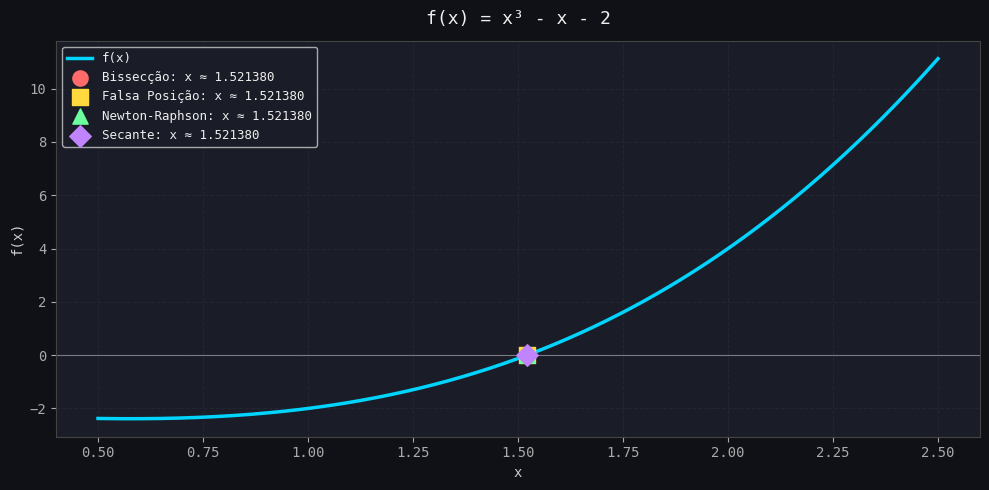

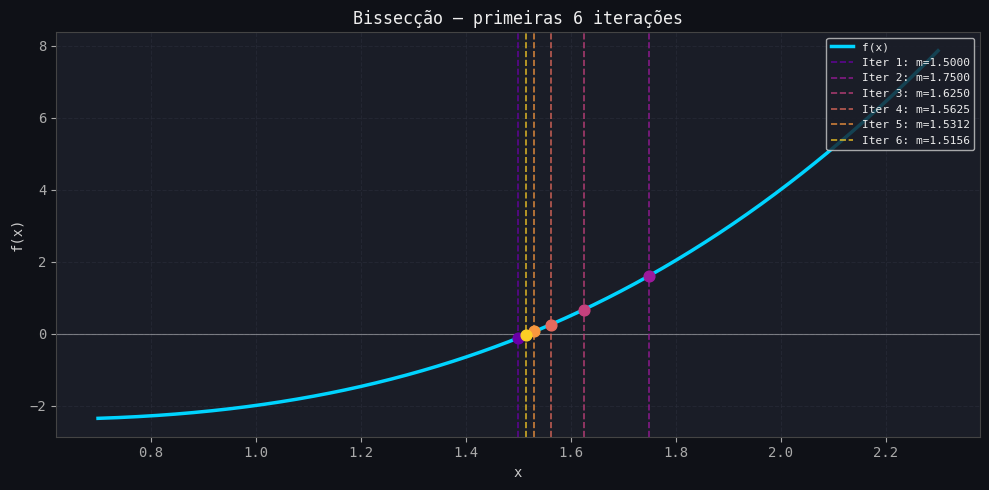

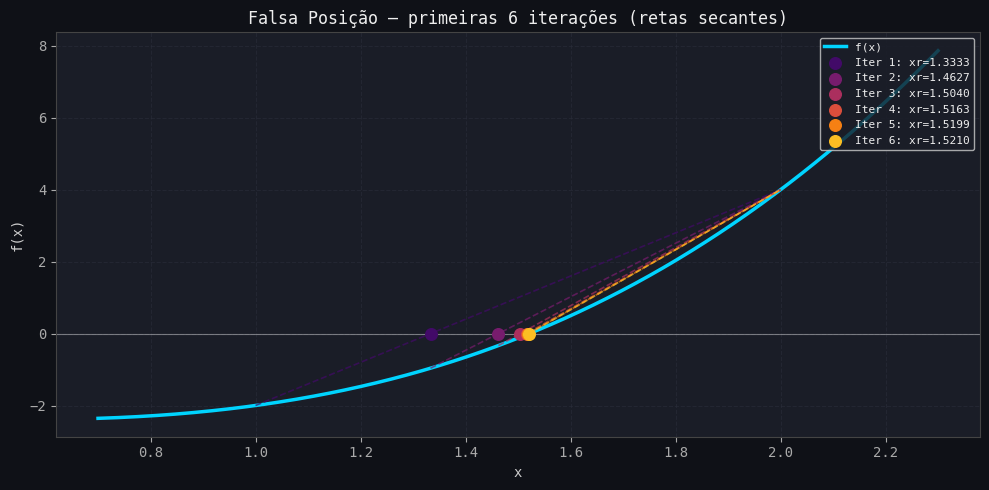

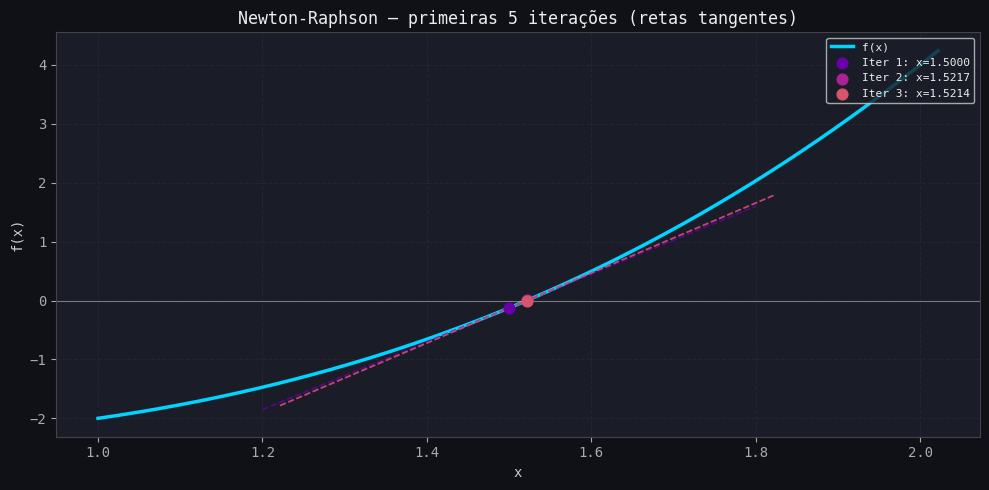

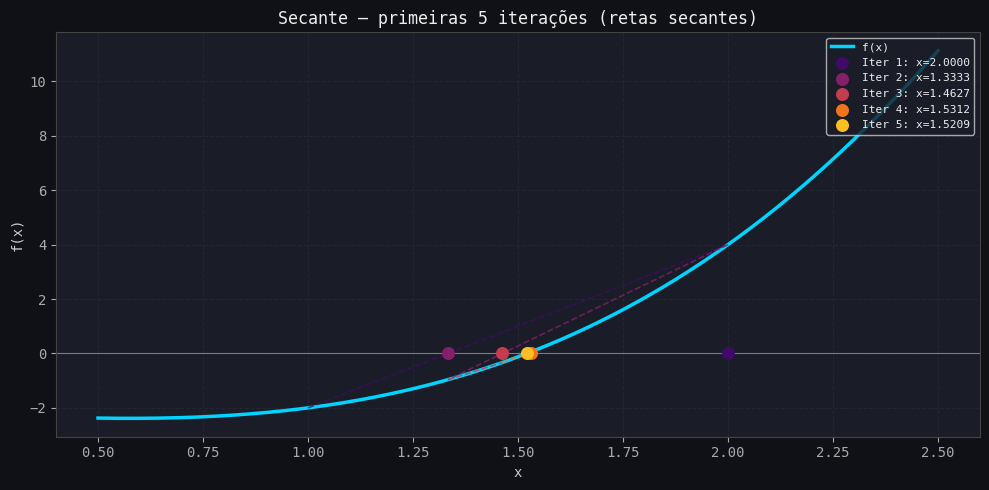

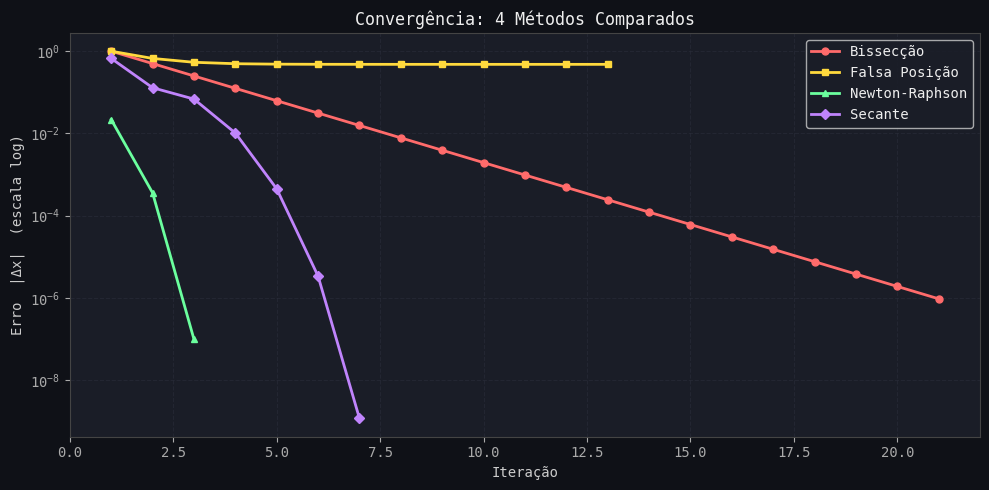

In [36]:
plotar_funcao_e_raiz_4_metodos(f1, 0.5, 2.5, raiz_b1, raiz_fp1, raiz_nr1, raiz_sec1,
                                titulo="f(x) = x³ - x - 2")
plotar_iteracoes_bisseccao(f1, hist_b1, a1, b1, n_mostrar=6)
plotar_iteracoes_falsa_posicao(f1, hist_fp1, a1, b1, n_mostrar=6)
plotar_iteracoes_newton(f1, df1, hist_nr1, x0=1.5, n_mostrar=5)
plotar_iteracoes_secante(f1, hist_sec1, n_mostrar=5)
plotar_convergencia_4_metodos(hist_b1, hist_fp1, hist_nr1, hist_sec1)

In [37]:
resumo_comparativo_4("x³ - x - 2", hist_b1, raiz_b1, hist_fp1, raiz_fp1,
                                    hist_nr1, raiz_nr1, hist_sec1, raiz_sec1)


──────────────────────────────────────────────────────────────────────────────
  Função: x³ - x - 2
  ────────────────────────────────────────────────────────────────────────────
  Critério                        Bissecção   Falsa Pos.     Newton    Secante
  ────────────────────────────────────────────────────────────────────────────
  Raiz encontrada                  1.521380     1.521380   1.521380   1.521380
  Nº de iterações                        21           13          3          7
──────────────────────────────────────────────────────────────────────────────


---

## Exemplos do livro: Aplicação Real dos 4 Métodos

> Exercícios extraídos de **"Métodos Numéricos: exercícios resolvidos aplicados à Engenharia e outras Ciências"**  
> Maria Teresa Torres Monteiro — Universidade do Minho, 2012


### Primeiro exemplo do livro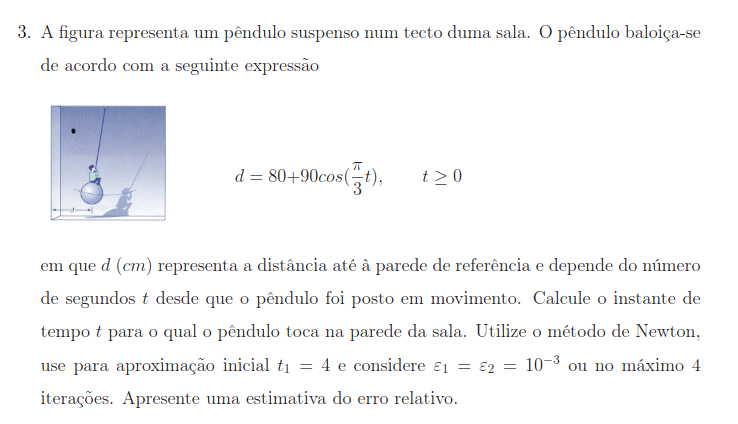

---
#### **Exercício 3 (pág. 10) — Instante em que toca na parede**

Reformulando como $f(t) = 0$:

$$f(x) = 80 + 90\cos\!\left(\frac{\pi}{3}\,x\right) = 0$$

Derivada (para Newton-Raphson):

$$f'(x) = -30\pi\,\sin\!\left(\frac{\pi}{3}\,x\right)$$

**Aqui:** aplicamos os 4 métodos com intervalo $[3.0,\, 3.5]$, $\varepsilon = 10^{-6}$.  
A raiz real (verificada numericamente) é $t^* \approx 3.4544$ s.


#### Definição da função do primeiro exercício

In [38]:
# Primeiro exemplo do livro
# d(t) = 80 + 90*cos(pi/3 * t) = 0
# Raiz real entre 3.0 e 3.5

def f_pendulo(x):
    return 80 + 90 * np.cos(np.pi / 3 * x)

def df_pendulo(x):
    return -30 * np.pi * np.sin(np.pi / 3 * x)

a_p, b_p = 3.0, 3.5   # intervalo com troca de sinal verificada
x0_p = 4.0 # chute inicial solicitado

print("=" * 74)
print("\tPêndulo: f(x) = 80 + 90·cos(π/3·x)  |  Intervalo [3.0, 3.5]")
print("=" * 74)
verificar_intervalo(f_pendulo, a_p, b_p)


	Pêndulo: f(x) = 80 + 90·cos(π/3·x)  |  Intervalo [3.0, 3.5]
Intervalo válido: f(3.0) = -10.0000  |  f(3.5) = 2.0577
   f(a)·f(b) = -20.5771 < 0  -> Existe raiz em [3.0, 3.5]


True

#### Métodos aplicados na questão do Pêndulo

##### **Bissecção**

In [39]:
print("\n BISSECÇÃO\n")
raiz_b_p, hist_b_p = bisseccao(f_pendulo, a_p, b_p, tol=1e-6)



 BISSECÇÃO

 Iter            a            b            m           f(m)        |b-a|
-------------------------------------------------------------------------
    1     3.000000     3.500000     3.250000    -6.93332437     5.00e-01
    2     3.250000     3.500000     3.375000    -3.14915793     2.50e-01
    3     3.375000     3.500000     3.437500    -0.71854674     1.25e-01
    4     3.437500     3.500000     3.468750     0.62708621     6.25e-02
    5     3.437500     3.468750     3.453125    -0.05644679     3.12e-02
    6     3.453125     3.468750     3.460938     0.28265188     1.56e-02
    7     3.453125     3.460938     3.457031     0.11243416     7.81e-03
    8     3.453125     3.457031     3.455078     0.02782641     3.91e-03
    9     3.453125     3.455078     3.454102    -0.01435203     1.95e-03
   10     3.454102     3.455078     3.454590     0.00672674     9.77e-04
   11     3.454102     3.454590     3.454346    -0.00381526     4.88e-04
   12     3.454346     3.454590     3

##### **Falsa Posição**

In [40]:
print("\n FALSA POSIÇÃO\n")
raiz_fp_p, hist_fp_p = falsa_posicao(f_pendulo, a_p, b_p, tol=1e-6)



 FALSA POSIÇÃO

 Iter            a            b           xr          f(xr)        |b-a|
-------------------------------------------------------------------------
    1     3.000000     3.500000     3.414672    -1.64695970     5.00e-01
    2     3.414672     3.500000     3.452606    -0.07879190     8.53e-02
    3     3.452606     3.500000     3.454354    -0.00347154     4.74e-02
    4     3.454354     3.500000     3.454431    -0.00015239     4.56e-02
    5     3.454431     3.500000     3.454434    -0.00000669     4.56e-02
    6     3.454434     3.500000     3.454434    -0.00000029     4.56e-02

Raiz encontrada: x ≈ 3.45443407  |  f(x) ≈ -2.94e-07  |  Iterações: 6


##### **Newton-Raphson**

In [41]:
print("\n NEWTON-RAPHSON  (x0 = 3.0)\n")
raiz_nr_p, hist_nr_p = newton_raphson(f_pendulo, df_pendulo, x0=x0_p, tol=1e-6)



 NEWTON-RAPHSON  (x0 = 3.0)

 Iter              x           f(x)          f'(x)         |Δx|
    1     4.00000000    35.00000000      81.620971     4.29e-01
    2     3.57118864     5.62577414      53.072097     1.06e-01
    3     3.46518615     0.46930439      44.117582     1.06e-02
    4     3.45454857     0.00494421      43.187106     1.14e-04
    5     3.45443409     0.00000057      43.177062     1.33e-08

Raiz encontrada: x ≈ 3.45443407  |  f(x) ≈ 0.00e+00  |  Iterações: 5


##### **Método da Secante**

In [42]:
print("\n MÉTODO DA SECANTE  (x0 = 3.0, x1 = 3.5)\n")
raiz_sec_p, hist_sec_p = secante(f_pendulo, x0=a_p, x1=b_p, tol=1e-6)



 MÉTODO DA SECANTE  (x0 = 3.0, x1 = 3.5)

 Iter          x_ant              x           f(x)         |Δx|
-----------------------------------------------------------------
    1     3.00000000     3.50000000     2.05771366     8.53e-02
    2     3.50000000     3.41467231    -1.64695970     3.79e-02
    3     3.41467231     3.45260582    -0.07879190     1.91e-03
    4     3.45260582     3.45451177     0.00335512     7.78e-05
    5     3.45451177     3.45443393    -0.00000624     1.45e-07

Raiz encontrada: x ≈ 3.45443407  |  f(x) ≈ -4.93e-10  |  Iterações: 5


#### Gráficos — Pêndulo

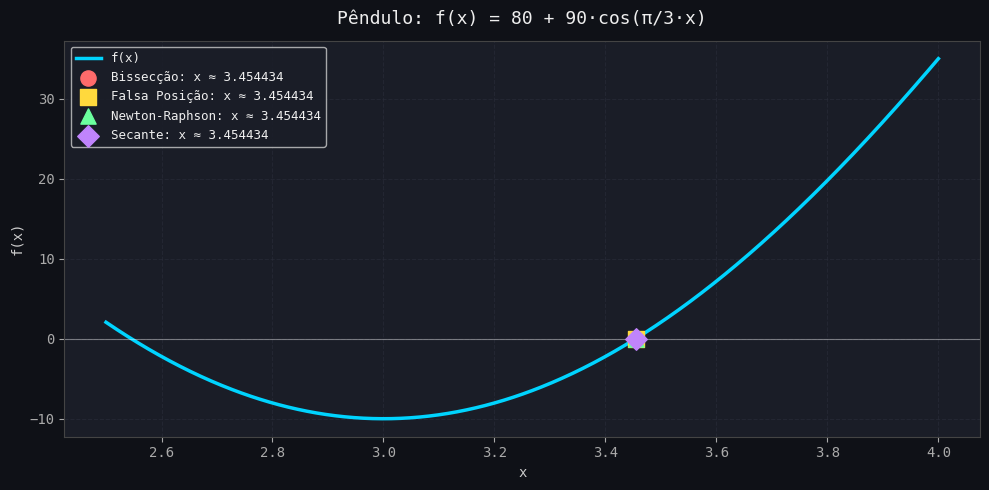

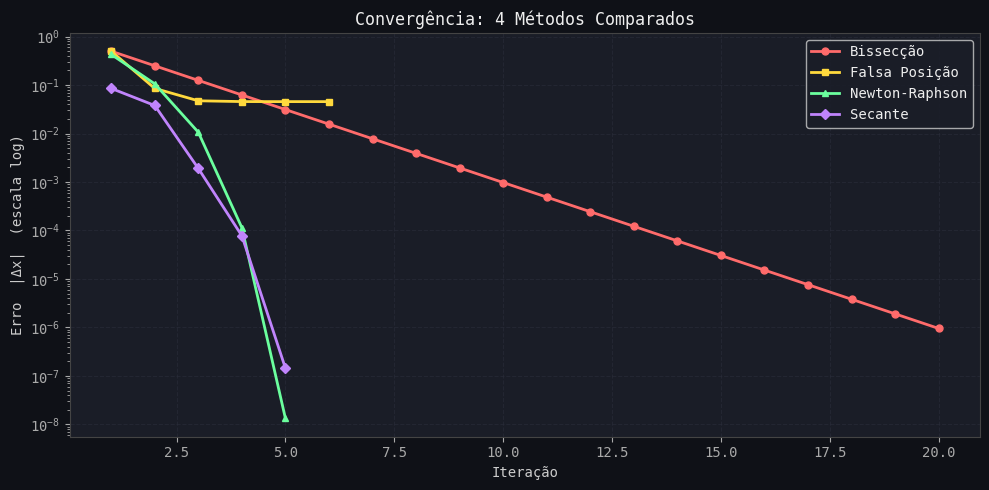

In [43]:
plotar_funcao_e_raiz_4_metodos(
    f_pendulo, 2.5, 4.0,
    raiz_b_p, raiz_fp_p, raiz_nr_p, raiz_sec_p,
    titulo="Pêndulo: f(x) = 80 + 90·cos(π/3·x)"
)
plotar_convergencia_4_metodos(hist_b_p, hist_fp_p, hist_nr_p, hist_sec_p)


#### Tabela Comparativa — Pêndulo

In [44]:
resumo_comparativo_4(
    "f(x) = 80 + 90·cos(π/3·x)  [Pêndulo]",
    hist_b_p,   raiz_b_p,
    hist_fp_p,  raiz_fp_p,
    hist_nr_p,  raiz_nr_p,
    hist_sec_p, raiz_sec_p
)
print(f"\n  Raiz real (verificada): t* ≈ 3.45443407 s")
print(f"  Solução Newton-Raphson (tol=1e-6):  t* ≈ {raiz_nr_p:.8f} s")



──────────────────────────────────────────────────────────────────────────────
  Função: f(x) = 80 + 90·cos(π/3·x)  [Pêndulo]
  ────────────────────────────────────────────────────────────────────────────
  Critério                        Bissecção   Falsa Pos.     Newton    Secante
  ────────────────────────────────────────────────────────────────────────────
  Raiz encontrada                  3.454434     3.454434   3.454434   3.454434
  Nº de iterações                        20            6          5          5
──────────────────────────────────────────────────────────────────────────────

  Raiz real (verificada): t* ≈ 3.45443407 s
  Solução Newton-Raphson (tol=1e-6):  t* ≈ 3.45443407 s


---
### Segundo exemplo do livro:

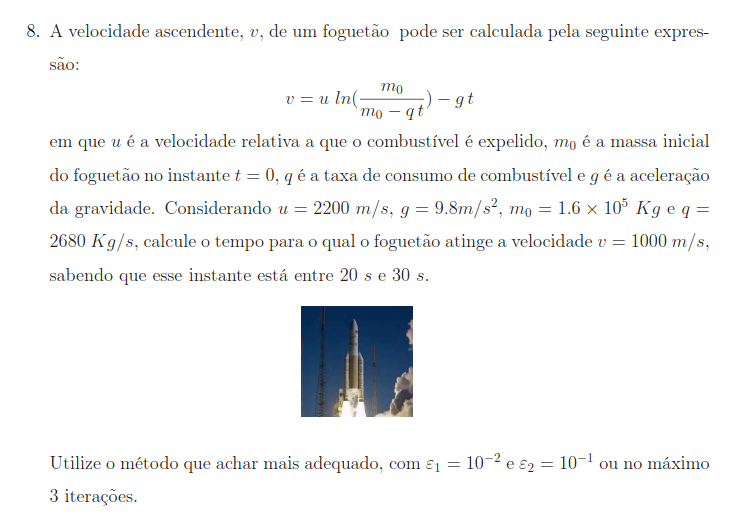

---
#### **Exercício 8 (pág. 21) - Tempo para atingir velocidade alvo**

Reformulando como $f(t) = 0$:

$$f(x) = 2200\ln\!\left(\frac{160000}{160000 - 2680x}\right) - 9.8x - 1000 = 0$$

Derivada:

$$f'(x) = \frac{2200 \times 2680}{160000 - 2680x} - 9.8$$

**Aqui:** aplicamos os 4 métodos com intervalo $[25, 26]$, $\varepsilon = 10^{-6}$.


#### Definição da função pro segundo exercício

In [45]:
# Exemplo do livro
# f(x) = 2200*ln(160000/(160000 - 2680*x)) - 9.8*x - 1000 = 0

def f_foguete(x):
    return 2200 * np.log(160000 / (160000 - 2680 * x)) - 9.8 * x - 1000

def df_foguete(x):
    return 2200 * 2680 / (160000 - 2680 * x) - 9.8

a_f, b_f = 25.0, 26.0   # intervalo com troca de sinal
x0_f = 25.0 # chute inicial para o método de Newton-Raphson

print("=" * 84)
print("\tFoguetão: v(t) = 2200·ln(160000/(160000-2680t)) - 9.8t  |  [25, 26]")
print("=" * 84)

# verificando o teorema de bolzano -> garante que a equação possui solução naquele intervalo
verificar_intervalo(f_foguete, a_f, b_f)


	Foguetão: v(t) = 2200·ln(160000/(160000-2680t)) - 9.8t  |  [25, 26]
Intervalo válido: f(25.0) = -51.3365  |  f(26.0) = 3.1928
   f(a)·f(b) = -163.9056 < 0  -> Existe raiz em [25.0, 26.0]


True

#### Métodos aplicados na questão do Foguetão

##### **Bissecção**

In [46]:
print("\n BISSECÇÃO\n")
raiz_b_f, hist_b_f = bisseccao(f_foguete, a_f, b_f, tol=1e-6)



 BISSECÇÃO

 Iter            a            b            m           f(m)        |b-a|
-------------------------------------------------------------------------
    1    25.000000    26.000000    25.500000   -24.30698046     1.00e+00
    2    25.500000    26.000000    25.750000   -10.61674930     5.00e-01
    3    25.750000    26.000000    25.875000    -3.72701082     2.50e-01
    4    25.875000    26.000000    25.937500    -0.27088965     1.25e-01
    5    25.937500    26.000000    25.968750     1.45999607     6.25e-02
    6    25.937500    25.968750    25.953125     0.59431742     3.12e-02
    7    25.937500    25.953125    25.945312     0.16165497     1.56e-02
    8    25.937500    25.945312    25.941406    -0.05463207     7.81e-03
    9    25.941406    25.945312    25.943359     0.05350777     3.91e-03
   10    25.941406    25.943359    25.942383    -0.00056307     1.95e-03
   11    25.942383    25.943359    25.942871     0.02647212     9.77e-04
   12    25.942383    25.942871    25

##### **Falsa Posição**

In [47]:
print("\n FALSA POSIÇÃO\n")
raiz_fp_f, hist_fp_f = falsa_posicao(f_foguete, a_f, b_f, tol=1e-6)



 FALSA POSIÇÃO

 Iter            a            b           xr          f(xr)        |b-a|
-------------------------------------------------------------------------
    1    25.000000    26.000000    25.941449    -0.05229268     1.00e+00
    2    25.941449    26.000000    25.942392    -0.00005252     5.86e-02
    3    25.942392    26.000000    25.942393    -0.00000005     5.76e-02

Raiz encontrada: x ≈ 25.94239298  |  f(x) ≈ -5.28e-08  |  Iterações: 3


##### **Newton-Raphson**

In [48]:
print("\n NEWTON-RAPHSON  (x0 = 25.0)\n")
raiz_nr_f, hist_nr_f = newton_raphson(f_foguete, df_foguete, x0=x0_f, tol=1e-6)



 NEWTON-RAPHSON  (x0 = 25.0)

 Iter              x           f(x)          f'(x)         |Δx|
    1    25.00000000   -51.33649142      53.597849     9.58e-01
    2    25.95780879     0.85376604      55.397387     1.54e-02
    3    25.94239713     0.00022939      55.367623     4.14e-06
    4    25.94239298     0.00000000      55.367615     2.92e-13

Raiz encontrada: x ≈ 25.94239298  |  f(x) ≈ 4.55e-13  |  Iterações: 4


##### **Método da Secante**

In [49]:
print("\n MÉTODO DA SECANTE  (x0 = 25.0, x1 = 26.0)\n")
raiz_sec_f, hist_sec_f = secante(f_foguete, x0=a_f, x1=b_f, tol=1e-6)



 MÉTODO DA SECANTE  (x0 = 25.0, x1 = 26.0)

 Iter          x_ant              x           f(x)         |Δx|
-----------------------------------------------------------------
    1    25.00000000    26.00000000     3.19276986     5.86e-02
    2    26.00000000    25.94144850    -0.05229268     9.44e-04
    3    25.94144850    25.94239203    -0.00005252     9.49e-07

Raiz encontrada: x ≈ 25.94239298  |  f(x) ≈ 8.65e-10  |  Iterações: 3


#### Gráficos — Foguetão

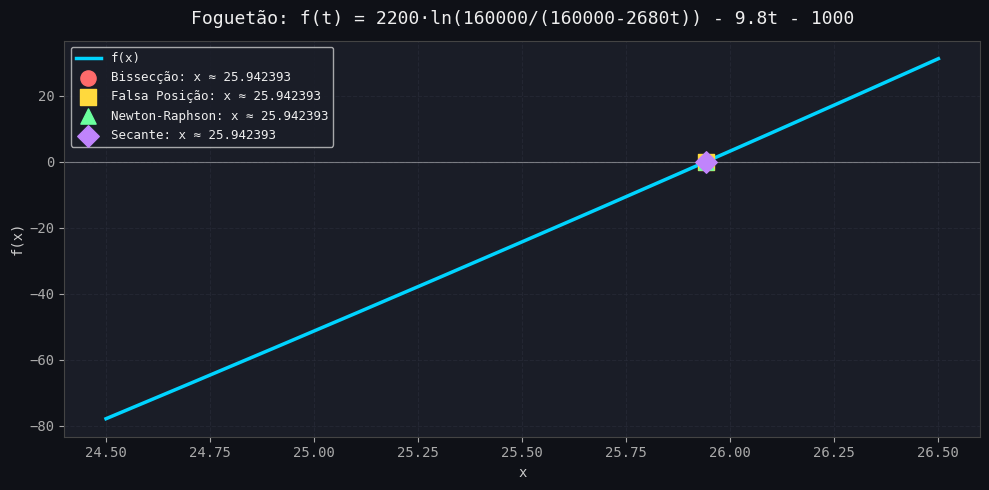

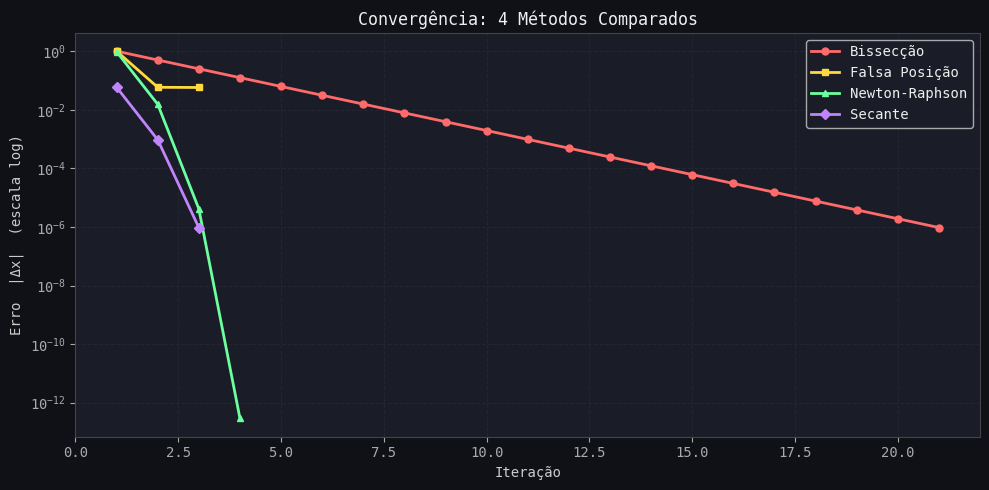

In [50]:
plotar_funcao_e_raiz_4_metodos(
    f_foguete, 24.5, 26.5,
    raiz_b_f, raiz_fp_f, raiz_nr_f, raiz_sec_f,
    titulo="Foguetão: f(t) = 2200·ln(160000/(160000-2680t)) - 9.8t - 1000"
)
plotar_convergencia_4_metodos(hist_b_f, hist_fp_f, hist_nr_f, hist_sec_f)


#### Tabela Comparativa

In [51]:
resumo_comparativo_4(
    "Foguetão: v(t) = 1000 m/s",
    hist_b_f,   raiz_b_f,
    hist_fp_f,  raiz_fp_f,
    hist_nr_f,  raiz_nr_f,
    hist_sec_f, raiz_sec_f
)
print(f"\n  Solução do livro (Secante, tol=1e-2): t* ≈ 25.9426 s")
print(f"  Solução numérica (tol=1e-6):           t* ≈ {raiz_nr_f:.6f} s")



──────────────────────────────────────────────────────────────────────────────
  Função: Foguetão: v(t) = 1000 m/s
  ────────────────────────────────────────────────────────────────────────────
  Critério                        Bissecção   Falsa Pos.     Newton    Secante
  ────────────────────────────────────────────────────────────────────────────
  Raiz encontrada                 25.942393    25.942393  25.942393  25.942393
  Nº de iterações                        21            3          4          3
──────────────────────────────────────────────────────────────────────────────

  Solução do livro (Secante, tol=1e-2): t* ≈ 25.9426 s
  Solução numérica (tol=1e-6):           t* ≈ 25.942393 s


---
### Comparação Geral — Os Dois Exemplos do Livro


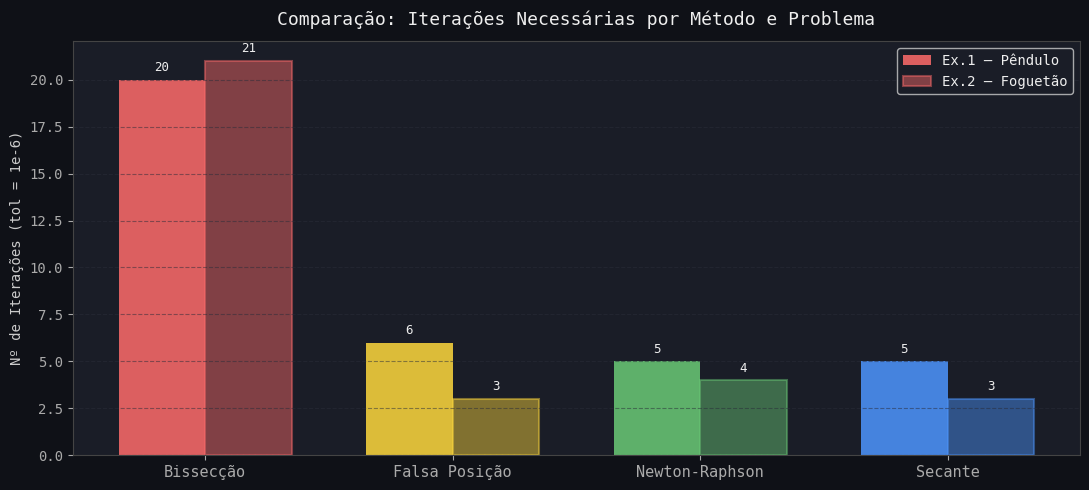


────────────────────────────────────────────────────────────────────────
  Método               Pêndulo (iter)   Foguetão (iter)   Usa derivada?
────────────────────────────────────────────────────────────────────────
  Bissecção                        20                21             Não
  Falsa Posição                     6                 3             Não
  Newton-Raphson                    5                 4             Sim
  Secante                           5                 3             Não
────────────────────────────────────────────────────────────────────────

  ✔  Newton-Raphson e Secante convergem em menos iterações.
  ✔  Bissecção garante convergência mesmo sem derivada, mas é mais lenta.
  ✔  Falsa Posição é um balanço: sem derivada, geralmente mais rápida que Bissecção.


In [52]:
labels  = ['Bissecção', 'Falsa Posição', 'Newton-Raphson', 'Secante']
iters_p = [len(hist_b_p), len(hist_fp_p), len(hist_nr_p), len(hist_sec_p)]
iters_f = [len(hist_b_f), len(hist_fp_f), len(hist_nr_f), len(hist_sec_f)]

cores = ['#ff6b6b', '#ffd93d', '#6bcb77', '#4d96ff']
x_pos = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x_pos - width/2, iters_p, width, label='Ex.1 — Pêndulo',   color=cores, alpha=0.85)
bars2 = ax.bar(x_pos + width/2, iters_f, width, label='Ex.2 — Foguetão',  color=cores, alpha=0.45,
               edgecolor=cores, linewidth=1.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Nº de Iterações (tol = 1e-6)', fontsize=10)
ax.set_title('Comparação: Iterações Necessárias por Método e Problema', fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.5)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.annotate(str(int(h)),
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=9, color='#eee')

plt.tight_layout()
plt.show()

print()
print("─" * 72)
print(f"  {'Método':<18} {'Pêndulo (iter)':>16} {'Foguetão (iter)':>17} {'Usa derivada?':>15}")
print("─" * 72)
for lab, ip, iff in zip(labels, iters_p, iters_f):
    deriv = 'Sim' if lab == 'Newton-Raphson' else 'Não'
    print(f"  {lab:<18} {ip:>16d} {iff:>17d} {deriv:>15}")
print("─" * 72)
print()
print("  ✔  Newton-Raphson e Secante convergem em menos iterações.")
print("  ✔  Bissecção garante convergência mesmo sem derivada, mas é mais lenta.")
print("  ✔  Falsa Posição é um balanço: sem derivada, geralmente mais rápida que Bissecção.")


## Conclusão


### Tabela de comparação dos métodos


In [53]:
print(f"{'─'*116}")
print(f"  {'Aspecto':<37} {'Bissecção':<20} {'Falsa Posição':<20} {'Newton-Raphson':<20} {'Secante':<15}")
print(f"  {'─'*114}")
print(f"  {'Convergência garantida':<37} {'Sim':<20} {'Sim':<20} {'Depende de x₀':<20} {'Depende de x₀,x₁':<15}")
print(f"  {'Ordem de convergência':<37} {'Linear (1/2)':<20} {'Linear (lenta)':<20} {'Quadrática':<20} {'≈ 1.618':<15}")
print(f"  {'Requer intervalo [a,b]':<37} {'Sim':<20} {'Sim':<20} {'Não':<20} {'Não':<15}")
col = "Requer derivada f'(x)"
print(f"  {col:<37} {'Não':<20} {'Não':<20} {'Sim':<20} {'Não':<15}")
print(f"  {'Pontos iniciais necessários':<37} {'2 (intervalo)':<20} {'2 (intervalo)':<20} {'1':<20} {'2':<15}")
print(f"{'─'*116}")

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Aspecto                               Bissecção            Falsa Posição        Newton-Raphson       Secante        
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Convergência garantida                Sim                  Sim                  Depende de x₀        Depende de x₀,x₁
  Ordem de convergência                 Linear (1/2)         Linear (lenta)       Quadrática           ≈ 1.618        
  Requer intervalo [a,b]                Sim                  Sim                  Não                  Não            
  Requer derivada f'(x)                 Não                  Não                  Sim                  Não            
  Pontos iniciais necessários           2 (intervalo)        2 (intervalo)        1                    2              
───────────────────────────────────────────────────

### Quando usar cada método


In [54]:
sep = "─" * 95
print(sep)
print(f"  {'Método':<25} {'Quando usar'}")
print("  " + "─" * 93)
print(f"  {'Bissecção':<25} Convergência garantida e previsível")
print(f"  {'Falsa Posição':<25} Convergência mais rápida e função bem comportada no intervalo")
print(f"  {'Newton-Raphson':<25} Convergência rápida e derivada disponível analiticamente")
print(f"  {'Secante':<25} Convergência rápida sem necessidade de calcular derivada")
print(sep)

───────────────────────────────────────────────────────────────────────────────────────────────
  Método                    Quando usar
  ─────────────────────────────────────────────────────────────────────────────────────────────
  Bissecção                 Convergência garantida e previsível
  Falsa Posição             Convergência mais rápida e função bem comportada no intervalo
  Newton-Raphson            Convergência rápida e derivada disponível analiticamente
  Secante                   Convergência rápida sem necessidade de calcular derivada
───────────────────────────────────────────────────────────────────────────────────────────────
